<a href="https://colab.research.google.com/github/ramireddyvennapusa/NPS-Ticketing-System-Data-Audit-Trend-Analysis-and-KPI-Dashboard/blob/main/Scaler_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Data Quality & Validation

Data Audit

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Assignment Data_ NPS Tracker_2025.xlsx to Assignment Data_ NPS Tracker_2025.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
file_name = "Assignment Data_ NPS Tracker_2025.xlsx"
df = pd.read_excel(file_name)

In [ ]:
display(df.shape)

(225, 17)

In [ ]:
df.head()

,Ticket No,Created Date,Created Time,Assigned To,Resolved Date,Resolved Time,Landing Folder,Disposition Folder Level 1,Disposition Folder Level 2,Phone,Email,Ticket All Remarks,Program Name,Issue 2 - NPS,NPS Rating,Status,Sub Status
0,75591735734,2025-08-23,18:16:02,Mike Chen,2025-08-30,17:21:01,Counselling Team - NPS,Counselling Team - NPS,Tech (NPS),9562254028,learner001@example.com,No code review feedback provided for assignmen...,Academy,Projects & Assignment Related Concern (NPS),6,Complete,Solved
1,75958260221,2025-09-02,17:43:46,David Wilson,2025-09-12,12:16:02,Counselling Team - NPS,Counselling Team - NPS,Program & Classroom (NPS),8564319318,learner002@example.com,No code review feedback provided for assignmen...,DSML,Projects & Assignment Related Concern (NPS),3,Complete,Solved
2,75838508549,2025-09-12,14:25:44,Lisa Rodriguez,NaN,NaN,Counselling Team - NPS,Counselling Team - NPS,Tech (NPS),9381183483,learner003@example.com,Assignment datasets have data quality issues b...,DevOps,Projects & Assignment Related Concern (NPS),6,Pending,In Progress
3,75988343096,2025-09-13,09:19:18,David Wilson,2025-09-16,18:36:19,Counselling Team - NPS,Counselling Team - NPS,Others (NPS),8846355528,learner004@example.com,Live sessions scheduled during US client calls...,DSML,Time Management Related Concerns (NPS),1,Complete,Solved
4,75500273738,2025-09-13,12:43:19,David Wilson,2025-09-21,11:42:05,Counselling Team - NPS,Counselling Team - NPS,Tech (NPS),7855256552,learner005@example.com,Told course would take 6 months but curriculum...,DevOps,False Promise By Sales Team (NPS),8,Complete,Solved


In [ ]:
critical_cols = [
    'Ticket No','Created Date/Time','Assigned To',
    'Resolved Date/Time','Program Name','Issue 2',
    'Status','Sub Status'
]

In [ ]:
df = df.dropna(subset=['Ticket No'])

In [ ]:
text_cols = ['Assigned To','Program Name','Issue 2 - NPS','Status','Sub Status']
df[text_cols] = df[text_cols].fillna('Unknown')

In [ ]:
date_cols = ['Created Date','Resolved Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
pending_words = ['pending','open','in progress','awaiting']

mask_inconsistent = (
    df['Status'].str.lower().eq('complete') &
    df['Sub Status'].str.lower().str.contains('|'.join(pending_words), na=False)
)

df.loc[mask_inconsistent, 'Sub Status'] = 'Completed'
print("Corrected Sub-Status inconsistencies:", mask_inconsistent.sum())


Corrected Sub-Status inconsistencies: 6


In [ ]:
before = df.shape[0]
df = df.drop_duplicates()
print("Exact duplicates removed:", before - df.shape[0])

Exact duplicates removed: 0


In [ ]:
df = (
    df.sort_values(['Ticket No','Resolved Date'], ascending=[True,False])
      .drop_duplicates(subset=['Ticket No'], keep='first')
)
print("Shape after resolving conflicts:", df.shape)

Shape after resolving conflicts: (225, 17)


In [ ]:
clean_file = "NPS_Tracker_Cleaned.csv"
df.to_csv(clean_file, index=False)
files.download(clean_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Process Recommendations

## Process Recommendations

Based on the data quality issues identified during the data audit, the following data validation rules and standardized data entry procedures are recommended to prevent future issues:

### Data Validation Rules:

*   **Ticket No:**
    *   Ensure uniqueness for each ticket number.
    *   Implement format validation if there is a specific pattern.
*   **Created Date and Resolved Date:**
    *   Enforce a consistent date format (e.g., YYYY-MM-DD).
    *   Validate that 'Resolved Date' is not before 'Created Date'.
*   **Assigned To, Program Name, Issue 2 - NPS, Status, Sub Status:**
    *   Use predefined lists or dropdowns for data entry to ensure consistency and prevent typos.
*   **Status and Sub Status Consistency:**
    *   Implement a rule to prevent 'Sub Status' from indicating a pending state ('Pending', 'In Progress', 'Open') when the 'Status' is 'Complete'.
*   **NPS Rating:**
    *   Validate that the input is a numerical value within the expected range (e.g., 0-10).

### Recommended Standardized Data Entry Procedures:

*   **Training:** Provide comprehensive training on data entry guidelines and the importance of data accuracy.
*   **Structured Forms:** Utilize data entry forms with built-in validation to guide users and minimize errors.
*   **Regular Data Audits:** Conduct periodic checks to identify and address any new data quality issues.
*   **Documentation:** Maintain a clear data dictionary and documentation of data entry procedures.
*   **Feedback Mechanism:** Establish a system to provide feedback to data entry personnel on data quality issues and their impact.

# Task 2: Strategic Pattern Analysis

 Issue Prioritisation


In [ ]:
print(df.shape)
df.head()


(225, 17)


,Ticket No,Created Date,Created Time,Assigned To,Resolved Date,Resolved Time,Landing Folder,Disposition Folder Level 1,Disposition Folder Level 2,Phone,Email,Ticket All Remarks,Program Name,Issue 2 - NPS,NPS Rating,Status,Sub Status
172,75401166414,2025-08-20,12:30:04,Priya Sharma,2025-08-24,15:41:05,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),9549834042,learner173@example.com,Interested in startup environment but concerne...,Academy,Looking For Career Guidance (NPS),7,Complete,Solved
117,75407333788,2025-08-07,13:24:15,Carlos Martinez,2025-08-10,16:20:59,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),8146731886,learner118@example.com,Multiple interview rounds cleared but final se...,AIML,Applied for jobs but no satisfactory outcome (...,1,Complete,Solved
161,75410290140,2025-08-19,16:08:12,Jessica Kim,2025-08-25,16:39:03,Counselling Team - NPS,Counselling Team - NPS,Program & Classroom (NPS),9411976659,learner162@example.com,Screen sharing resolution too low during codin...,DevOps,Poor Class video quality (NPS),3,Complete,Solved
16,75413585139,2025-08-23,15:52:31,Mike Chen,2025-09-03,14:04:32,Counselling Team - NPS,Counselling Team - NPS,Program & Classroom (NPS),7437662764,learner017@example.com,Evening Academy Jul25 Beginner starts at 7 PM ...,DevOps,Unhappy With The Class Timings (NPS),5,Complete,Solved
178,75414810579,2025-08-12,13:13:02,Sarah Johnson,NaT,NaN,Counselling Team - NPS,Counselling Team - NPS,Program & Classroom (NPS),8709289717,learner179@example.com,Assignment instructions assume prior knowledge...,Academy,Projects & Assignment Related Concern (NPS),2,Pending,Awaiting Action - Scaler


In [ ]:
issue_freq = df['Issue 2 - NPS'].value_counts()
top5_issues = issue_freq.head(5)

print("Top 5 Critical Issues:\n", top5_issues)

Top 5 Critical Issues:
 Issue 2 - NPS
Looking For Career Guidance (NPS)                     21
Applied for jobs but no satisfactory outcome (NPS)    19
Projects & Assignment Related Concern (NPS)           18
False Promise By Sales Team (NPS)                     18
Time Management Related Concerns (NPS)                18
Name: count, dtype: int64


In [ ]:
cross_program = (
    df.groupby(['Program Name','Issue 2 - NPS'])
      .size()
      .reset_index(name='Ticket_Count')
      .sort_values('Ticket_Count', ascending=False)
)


cross_program.head(10)
cross_program.to_csv("Task2_cross_program_issues.csv", index=False)

In [ ]:
df['Created Date']  = pd.to_datetime(df['Created Date'],  errors='coerce')
df['Resolved Date'] = pd.to_datetime(df['Resolved Date'], errors='coerce')

In [ ]:
df['Resolution_Hours'] = (
    df['Resolved Date'] - df['Created Date']
).dt.total_seconds() / 3600

resolution_time_by_issue = (
    df.groupby('Issue 2 - NPS')['Resolution_Hours']
      .mean()
      .sort_values()
)

print("Average Resolution Hours by Issue:\n", resolution_time_by_issue)
resolution_time_by_issue.to_csv("Task2_resolution_by_issue.csv")

Average Resolution Hours by Issue:
 Issue 2 - NPS
Lecture Notes Related (NPS)                           126.545455
Unhappy With Course Curriculum (NPS)                  132.000000
Poor Class video quality (NPS)                        148.000000
Applied for jobs but no satisfactory outcome (NPS)    149.142857
Unhappy With The Class Timings (NPS)                  150.545455
TA Support Related Concerns (NPS)                     160.000000
Not eligible for placements (NPS)                     165.333333
Projects & Assignment Related Concern (NPS)           168.000000
False Promise By Sales Team (NPS)                     171.000000
Frequent Resume Rejection (NPS)                       175.200000
Time Management Related Concerns (NPS)                179.076923
Looking For Career Guidance (NPS)                     180.000000
Mentor Support Related Concerns (NPS)                 185.454545
Instructor Related Feedback (NPS)                     189.333333
Name: Resolution_Hours, dtype: float64


In [ ]:

most_helpful_fix = issue_freq.idxmax()
print("Single Fix Helping Most Learners:", most_helpful_fix)


Single Fix Helping Most Learners: Looking For Career Guidance (NPS)


Trend Analysis

Weekly Trend Preview:
 Week
2025-08-18/2025-08-24    35
2025-08-25/2025-08-31    34
2025-09-01/2025-09-07    18
2025-09-08/2025-09-14    33
2025-09-15/2025-09-21    34
dtype: int64


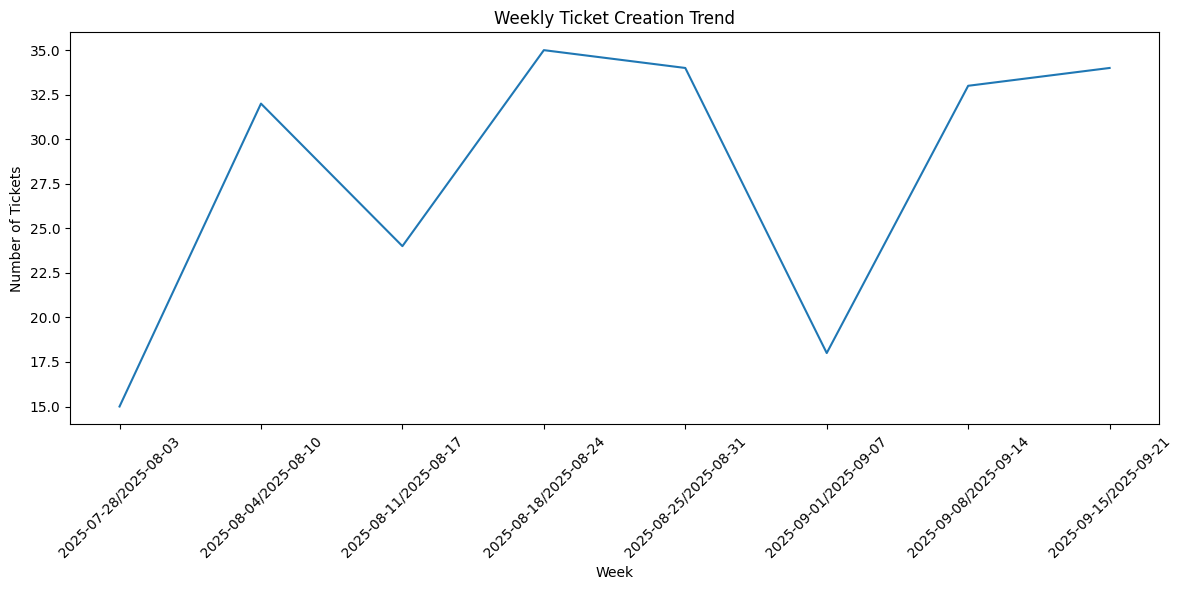

In [ ]:
# Weekly Trend Analysis and Visualization
df['Week'] = df['Created Date'].dt.to_period('W').astype(str)
weekly_trend = df.groupby('Week').size()
weekly_trend.to_csv("Task2_weekly_ticket_trend.csv")

print("Weekly Trend Preview:\n", weekly_trend.tail())

plt.figure(figsize=(12, 6))
weekly_trend.plot(kind='line')
plt.title('Weekly Ticket Creation Trend')
plt.xlabel('Week')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly Trend Preview:
 Month
2025-08    140
2025-09     85
dtype: int64


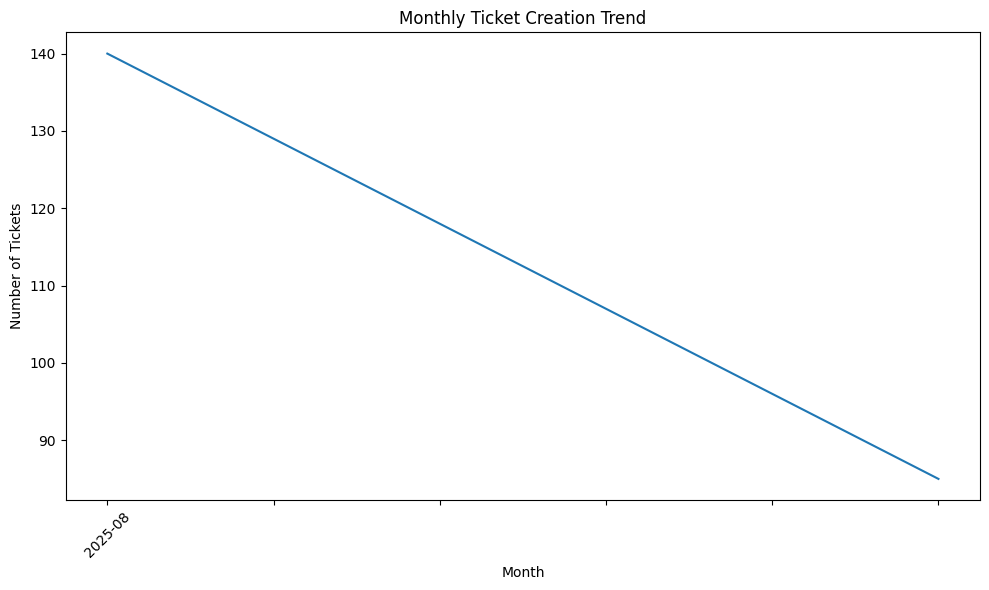

In [ ]:
# Monthly Trend Analysis and Visualization
df['Month'] = df['Created Date'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('Month').size()
monthly_trend.to_csv("Task2_monthly_ticket_trend.csv")

print("Monthly Trend Preview:\n", monthly_trend.tail())

plt.figure(figsize=(10, 6))
monthly_trend.plot(kind='line')
plt.title('Monthly Ticket Creation Trend')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Program Name,Issue 2 - NPS,Ticket_Count
0,AIML,Applied for jobs but no satisfactory outcome (...,8
48,DevOps,Mentor Support Related Concerns (NPS),7
37,DSML,Projects & Assignment Related Concern (NPS),7
24,Academy,TA Support Related Concerns (NPS),7
19,Academy,Looking For Career Guidance (NPS),6
23,Academy,Projects & Assignment Related Concern (NPS),6
22,Academy,Poor Class video quality (NPS),6
14,Academy,Applied for jobs but no satisfactory outcome (...,6
33,DSML,Looking For Career Guidance (NPS),6
29,DSML,False Promise By Sales Team (NPS),6


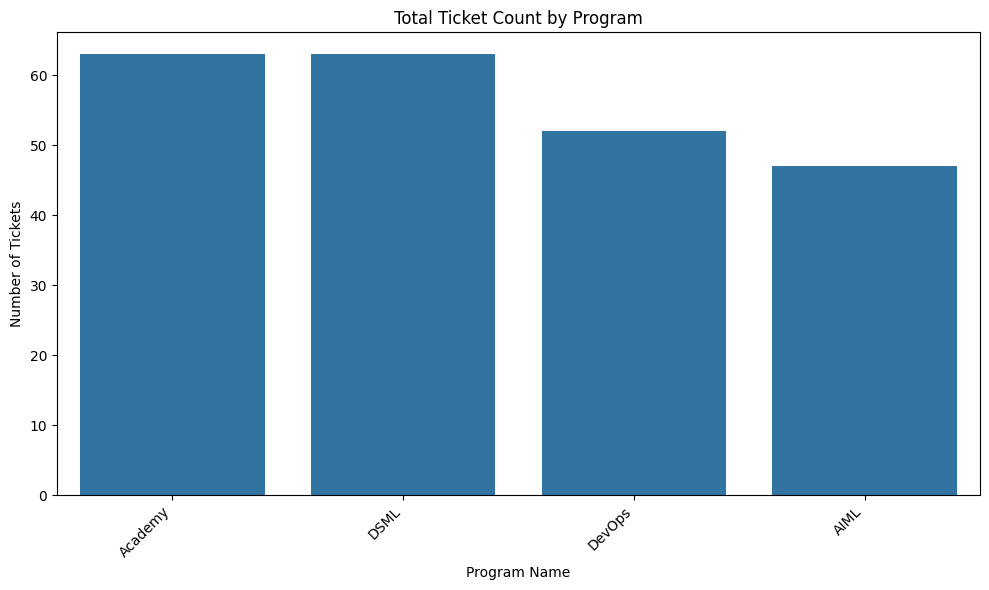

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

issue_distribution = (
    df.groupby(['Program Name','Issue 2 - NPS'])
      .size()
      .reset_index(name='Ticket_Count')
      .sort_values('Ticket_Count', ascending=False)
)

issue_distribution.to_csv("Task2_issue_distribution.csv", index=False)
display(issue_distribution.head(10))

# Visualize the total number of tickets per program for simplicity
program_ticket_counts = df['Program Name'].value_counts().reset_index()
program_ticket_counts.columns = ['Program Name', 'Ticket_Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=program_ticket_counts, x='Program Name', y='Ticket_Count')
plt.title('Total Ticket Count by Program')
plt.xlabel('Program Name')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average Resolution Hours by Team Member:
 Assigned To
Priya Sharma       116.800000
Amit Patel         139.200000
David Wilson       142.153846
Rohit Gupta        144.000000
Jessica Kim        158.709677
Carlos Martinez    162.461538
Lisa Rodriguez     163.764706
Mike Chen          188.000000
Sneha Reddy        213.818182
Sarah Johnson      222.545455
Unknown                   NaN
Name: Resolution_Hours, dtype: float64


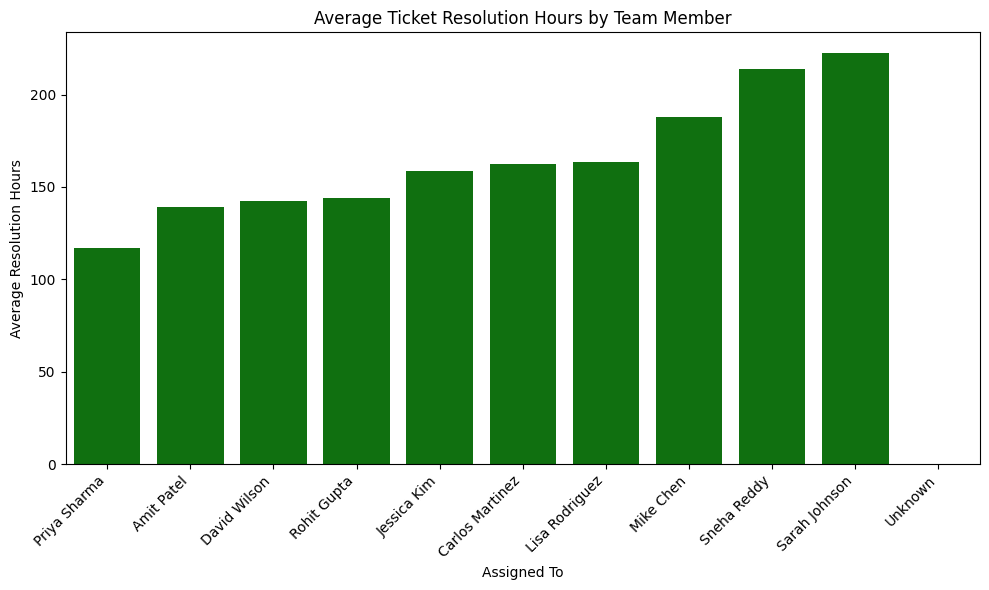

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

team_performance = (
    df.groupby('Assigned To')['Resolution_Hours']
      .mean()
      .sort_values()
)

print("Average Resolution Hours by Team Member:\n", team_performance)
team_performance.to_csv("Task2_team_performance.csv")

# Visualize average resolution hours by team member
plt.figure(figsize=(10, 6))
sns.barplot(x=team_performance.index, y=team_performance.values, color='green')
plt.title('Average Ticket Resolution Hours by Team Member')
plt.xlabel('Assigned To')
plt.ylabel('Average Resolution Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

,Month,Issue 2 - NPS,Ticket_Count
13,2025-08,Unhappy With The Class Timings (NPS),14
5,2025-08,Looking For Career Guidance (NPS),12
9,2025-08,Projects & Assignment Related Concern (NPS),12
0,2025-08,Applied for jobs but no satisfactory outcome (...,11
2,2025-08,Frequent Resume Rejection (NPS),11
4,2025-08,Lecture Notes Related (NPS),11
6,2025-08,Mentor Support Related Concerns (NPS),10
10,2025-08,TA Support Related Concerns (NPS),10
1,2025-08,False Promise By Sales Team (NPS),9
7,2025-08,Not eligible for placements (NPS),9


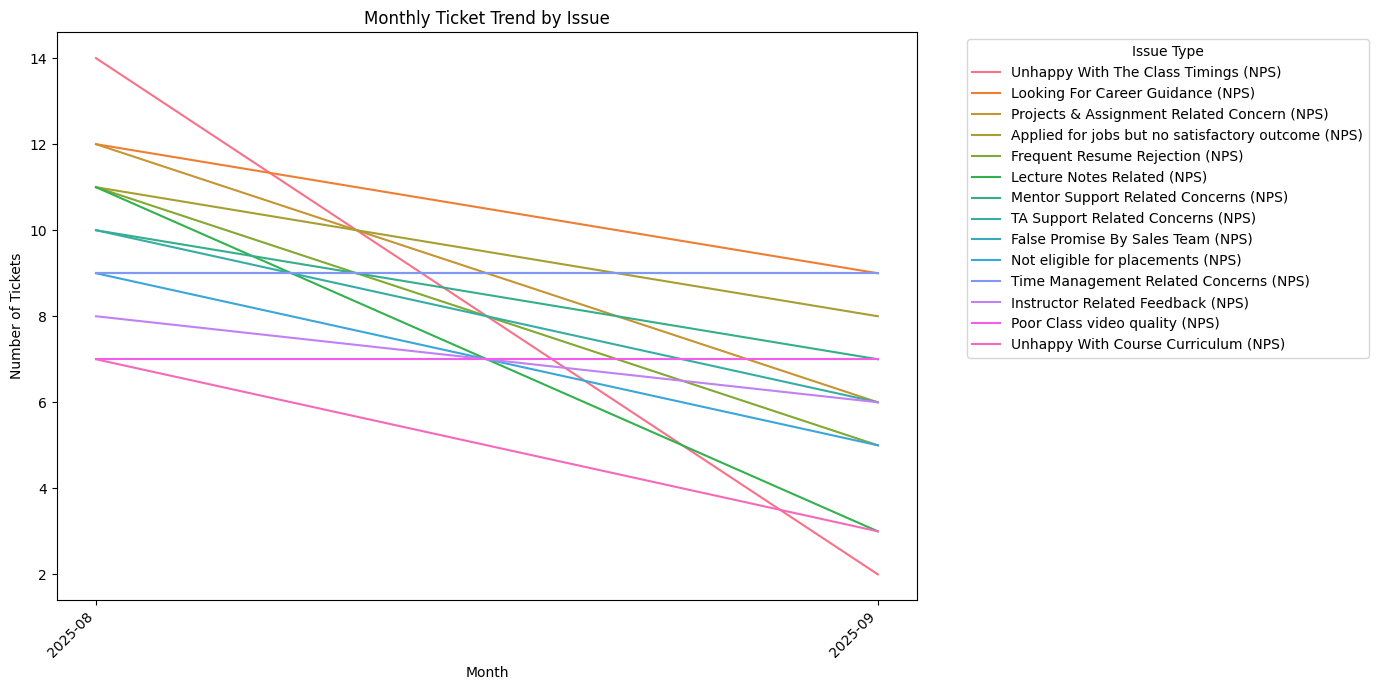

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly trend per issue to detect seasonal spikes
seasonal_patterns = (
    df.groupby(['Month','Issue 2 - NPS'])
      .size()
      .reset_index(name='Ticket_Count')
      .sort_values(['Month','Ticket_Count'], ascending=[True,False])
)

seasonal_patterns.to_csv("Task2_seasonal_patterns.csv", index=False)
display(seasonal_patterns.head(10))

# Visualize monthly trend per issue
plt.figure(figsize=(14, 7))
sns.lineplot(data=seasonal_patterns, x='Month', y='Ticket_Count', hue='Issue 2 - NPS')
plt.title('Monthly Ticket Trend by Issue')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Issue Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Task 3: Monitoring Framework

Root Cause Analysis

In [ ]:
# Top 3 issues by ticket frequency
top3_issues = df['Issue 2 - NPS'].value_counts().head(3)
print("=== Top 3 Critical Issues ===")
print(top3_issues)

# Records related to these top issues
critical_issues_df = df[df['Issue 2 - NPS'].isin(top3_issues.index)]
print("\nSample Records for Top Issues (first 5 rows):")
display(critical_issues_df.head())

=== Top 3 Critical Issues ===
Issue 2 - NPS
Looking For Career Guidance (NPS)                     21
Applied for jobs but no satisfactory outcome (NPS)    19
Projects & Assignment Related Concern (NPS)           18
Name: count, dtype: int64

Sample Records for Top Issues (first 5 rows):


,Ticket No,Created Date,Created Time,Assigned To,Resolved Date,Resolved Time,Landing Folder,Disposition Folder Level 1,Disposition Folder Level 2,Phone,Email,Ticket All Remarks,Program Name,Issue 2 - NPS,NPS Rating,Status,Sub Status,Resolution_Hours,Week,Month
172,75401166414,2025-08-20,12:30:04,Priya Sharma,2025-08-24,15:41:05,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),9549834042,learner173@example.com,Interested in startup environment but concerne...,Academy,Looking For Career Guidance (NPS),7,Complete,Solved,96.0,2025-08-18/2025-08-24,2025-08
117,75407333788,2025-08-07,13:24:15,Carlos Martinez,2025-08-10,16:20:59,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),8146731886,learner118@example.com,Multiple interview rounds cleared but final se...,AIML,Applied for jobs but no satisfactory outcome (...,1,Complete,Solved,72.0,2025-08-04/2025-08-10,2025-08
178,75414810579,2025-08-12,13:13:02,Sarah Johnson,NaT,NaN,Counselling Team - NPS,Counselling Team - NPS,Program & Classroom (NPS),8709289717,learner179@example.com,Assignment instructions assume prior knowledge...,Academy,Projects & Assignment Related Concern (NPS),2,Pending,Awaiting Action - Scaler,NaN,2025-08-11/2025-08-17,2025-08
125,75416799547,2025-08-23,12:13:04,Mike Chen,2025-08-27,10:02:51,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),9550970716,learner126@example.com,Contract/freelance offers available but seekin...,DSML,Applied for jobs but no satisfactory outcome (...,1,Complete,Solved,96.0,2025-08-18/2025-08-24,2025-08
210,75427633490,2025-08-01,12:10:40,Lisa Rodriguez,2025-08-06,18:30:12,Counselling Team - NPS,Counselling Team - NPS,Placement (NPS),7351912852,learner211@example.com,Geographic restrictions limiting opportunities...,Academy,Applied for jobs but no satisfactory outcome (...,7,Complete,Solved,120.0,2025-07-28/2025-08-03,2025-08


In [ ]:
# Count how many programs each critical issue spans
systemic_check = (
    critical_issues_df.groupby('Issue 2 - NPS')['Program Name']
    .nunique()
    .reset_index(name='Program_Count')
    .sort_values('Program_Count', ascending=False)
)
print("\n=== Systemic vs Isolated Check ===")
print(systemic_check.to_string(index=False))


=== Systemic vs Isolated Check ===
                                     Issue 2 - NPS  Program_Count
Applied for jobs but no satisfactory outcome (NPS)              4
                 Looking For Career Guidance (NPS)              4
       Projects & Assignment Related Concern (NPS)              4


In [ ]:
# Combine remarks for each critical issue
remarks_summary = (
    critical_issues_df.groupby('Issue 2 - NPS')['Ticket All Remarks']
    .apply(lambda x: " | ".join(x.astype(str)))
    .reset_index()
)
print("\n=== Consolidated Remarks (Truncated) ===")
for _, row in remarks_summary.iterrows():
    print(f"\nIssue: {row['Issue 2 - NPS']}\nRemarks: {row['Ticket All Remarks'][:500]}...")


=== Consolidated Remarks (Truncated) ===

Issue: Applied for jobs but no satisfactory outcome (NPS)
Remarks: Multiple interview rounds cleared but final selection goes to internal referrals. External candidates seem disadvantaged despite equal performance. || Resolution: Expanded alumni network for referral opportunities and insider advocacy | Contract/freelance offers available but seeking permanent positions with benefits and job security. Market seems tilted toward gig work. || Resolution: Targeted Microsoft outreach focusing on full-time opportunity pipeline | Geographic restrictions limiting oppor...

Issue: Looking For Career Guidance (NPS)
Remarks: Interested in startup environment but concerned about job security with family responsibilities. Need advice on evaluating startup opportunities vs established companies. || Resolution: Conducted detailed career counseling session on risk assessment and planning | Considering career break for higher studies (MS abroad). Need advice o

## Preventive Measures

Based on the Root Cause Analysis of the top critical issues, the following preventive measures are suggested:

*   **For "Looking For Career Guidance (NPS)" and "Applied for jobs but no satisfactory outcome (NPS)":**
    *   **Enhanced Career Services:** Strengthen career counseling services with dedicated sessions focusing on industry-specific job market trends, interview preparation, and networking strategies.
    *   **Alumni Network Engagement:** Facilitate stronger connections between current learners and alumni for mentorship, job referrals, and insights into different career paths.
    *   **Realistic Expectations Setting:** Ensure clear and realistic communication about job placement outcomes and timelines during the sales and onboarding process.
    *   **Targeted Job Search Support:** Provide tailored support based on individual learner profiles and career aspirations, including identifying relevant job opportunities and tailoring applications.

*   **For "Projects & Assignment Related Concern (NPS)":**
    *   **Curriculum Review and Alignment:** Regularly review and update the curriculum to ensure alignment between theoretical concepts taught in lectures and the practical skills required for assignments and projects.
    *   **Clearer Assignment Instructions and Prerequisites:** Provide detailed and unambiguous assignment instructions, clearly outlining any prerequisite knowledge or tools required. Offer supplementary materials or introductory sessions for necessary external tools (e.g., different database systems).
    *   **Project Scope and Time Allocation Review:** Assess the complexity and scope of projects to ensure they are realistic and achievable within the allocated timeframes, considering the learners' current skill levels.
    *   **Improved TA and Mentor Support:** Enhance the availability and responsiveness of Teaching Assistants (TAs) and mentors to provide timely assistance and guidance on project-related queries.

*   **General Systemic Issues:**
    *   **Cross-Program Collaboration:** Encourage collaboration and knowledge sharing between program teams to address systemic issues that cut across multiple programs.
    *   **Feedback Loop Implementation:** Establish a robust feedback loop from learners to the curriculum development and support teams to proactively identify and address issues.
    *   **Data-Driven Monitoring:** Continuously monitor key metrics (like issue frequency, resolution times, and NPS ratings) to track the effectiveness of preventive measures and identify new areas for improvement.

 KPI Dashboard Design

## Key Metrics for Monitoring (Weekly/Monthly)

Based on the strategic pattern analysis and root cause analysis, the following key metrics are recommended for regular monitoring to track performance, identify trends, and measure the impact of implemented preventive measures:

*   **Total Ticket Volume:** Track the total number of tickets created each week/month.
    *   *Purpose:* To understand the overall demand and identify significant increases or decreases in ticket volume.
*   **Ticket Volume by Issue Category:** Monitor the number of tickets for each 'Issue 2 - NPS' category weekly/monthly.
    *   *Purpose:* To track the prevalence of specific issues and identify any emerging critical issues or seasonal patterns.
*   **Ticket Volume by Program:** Track the number of tickets generated by each 'Program Name' weekly/monthly.
    *   *Purpose:* To understand the workload distribution across programs and identify programs with a high volume of tickets that might require targeted support.
*   **Average Ticket Resolution Time:** Monitor the average 'Resolution\_Hours' for all tickets, and potentially by issue category or assigned team member, on a weekly/monthly basis.
    *   *Purpose:* To assess the efficiency of the resolution process and identify bottlenecks or areas where resolution time is increasing.
*   **NPS Rating Distribution:** Track the distribution of NPS ratings (Promoters, Passives, Detractors) or the average NPS score weekly/monthly.
    *   *Purpose:* To gauge overall learner satisfaction and see how it correlates with ticket volume and types of issues.
*   **Tickets by Status (Open/Pending vs. Complete):** Monitor the number or percentage of tickets that are still open or pending resolution each week/month.
    *   *Purpose:* To understand the backlog and ensure tickets are being closed in a timely manner.
*   **Top N Issues' Trend:** Specifically track the weekly/monthly trend of the top 3-5 critical issues identified in the analysis.
    *   *Purpose:* To directly monitor the impact of preventive measures implemented for these key issues.
*   **Team Performance (Average Resolution Time/Tickets Resolved):** Monitor the average resolution time or the number of tickets resolved per assigned team member weekly/monthly.
    *   *Purpose:* To evaluate team performance and identify individuals or teams that might need additional support or training.

In [ ]:
# Monthly ticket volumes
kpi_monthly_tickets = df.groupby('Month').size()

# Overall average resolution time
kpi_avg_resolution = df['Resolution_Hours'].mean()

# Average resolution time by issue category
kpi_issue_resolution = (
    df.groupby('Issue 2 - NPS')['Resolution_Hours']
      .mean()
      .sort_values()
)

# Average resolution time by team member
kpi_team_performance = (
    df.groupby('Assigned To')['Resolution_Hours']
      .mean()
      .sort_values()
)

print("\n=== KPI Metrics ===")
print(f"Overall Avg Resolution Time (Hours): {kpi_avg_resolution:.2f}\n")

print("Monthly Ticket Volume:")
display(kpi_monthly_tickets)

print("\nAverage Resolution Hours by Issue:")
display(kpi_issue_resolution)

print("\nAverage Resolution Hours by Team Member:")
display(kpi_team_performance)


=== KPI Metrics ===
Overall Avg Resolution Time (Hours): 162.68

Monthly Ticket Volume:


,0
Month,
2025-08,140
2025-09,85



Average Resolution Hours by Issue:


,Resolution_Hours
Issue 2 - NPS,
Lecture Notes Related (NPS),126.545455
Unhappy With Course Curriculum (NPS),132.000000
Poor Class video quality (NPS),148.000000
Applied for jobs but no satisfactory outcome (NPS),149.142857
Unhappy With The Class Timings (NPS),150.545455
TA Support Related Concerns (NPS),160.000000
Not eligible for placements (NPS),165.333333
Projects & Assignment Related Concern (NPS),168.000000
False Promise By Sales Team (NPS),171.000000



Average Resolution Hours by Team Member:


,Resolution_Hours
Assigned To,
Priya Sharma,116.800000
Amit Patel,139.200000
David Wilson,142.153846
Rohit Gupta,144.000000
Jessica Kim,158.709677
Carlos Martinez,162.461538
Lisa Rodriguez,163.764706
Mike Chen,188.000000
Sneha Reddy,213.818182


## Review Stakeholders and Escalation Criteria

To ensure effective monitoring and timely action based on the defined KPIs, the following review stakeholders and escalation criteria are recommended:

### Review Stakeholders:

*   **Daily/Weekly Review:**
    *   **Assigned Team Members:** Responsible for reviewing their individual ticket queues, resolution times, and open/pending tickets.
    *   **Team Leads/Managers:** Review team-level performance metrics (average resolution time, tickets resolved), monitor ticket volume and status, and identify any immediate bottlenecks or issues requiring attention.
*   **Monthly Review:**
    *   **Program Managers:** Review ticket volume and issue distribution by program, analyze trends, and assess the impact of preventive measures on program-specific issues.
    *   **Support Team Leadership:** Review overall ticket volume, resolution times, team performance, and key issue trends. They are responsible for identifying systemic issues and allocating resources.
    *   **Curriculum Development Team (for relevant issues):** Review feedback and trends related to curriculum, assignments, and class quality to inform updates and improvements.
    *   **Sales/Marketing Team (for relevant issues):** Review feedback and trends related to false promises or unrealistic expectations set during the sales process.
*   **Quarterly/Strategic Review:**
    *   **Senior Leadership (e.g., Head of Operations, Program Directors):** Review high-level KPIs, long-term trends, the effectiveness of major interventions, and strategic alignment of support efforts.

### Escalation Criteria:

Establish clear criteria for when a ticket or an issue trend should be escalated to a higher level of review or action. Examples include:

*   **Stalled Tickets:** Tickets remaining in 'Pending' or 'In Progress' status for an unreasonable duration (e.g., > X days, where X is a defined threshold).
*   **High Severity Issues:** Tickets categorized under specific high-severity issue types that require immediate attention (e.g., issues impacting a large number of learners, critical system errors).
*   **Spikes in Ticket Volume:** A sudden and significant increase in overall ticket volume or in specific issue categories, indicating a potential widespread problem.
*   **Decreasing NPS Ratings:** A significant drop in overall NPS ratings or a negative trend in ratings associated with specific programs or issues.
*   **Increased Average Resolution Time:** A sustained increase in the average time it takes to resolve tickets, indicating potential inefficiencies or resource constraints.
*   **Systemic Issues:** Any issue identified as affecting multiple programs or a large segment of the learner base, requiring a coordinated response.
*   **Repeated Issues:** Individual learners repeatedly raising the same or similar issues, suggesting the root cause is not being addressed effectively.

Clearly documented escalation paths and responsibilities should be established to ensure timely and appropriate responses to critical situations.

## KPI Dashboard Structure Design

Based on the key metrics identified for weekly/monthly monitoring, here is a suggested structure for the KPI dashboard using descriptions:

**Dashboard Layout:**

*   The dashboard could be organized into several sections or tabs for clarity and ease of navigation.
*   Consider a layout that prioritizes the most critical metrics at the top or in a prominent area.

**Suggested Sections/Components:**

1.  **Overall Ticket Volume & Trends:**
    *   Line charts showing weekly and monthly total ticket creation trends (based on our analysis in Task 2).
    *   A clear display of the total number of tickets for the current week/month compared to the previous period.

2.  **Issue Prioritization & Distribution:**
    *   A bar chart showing the top N critical issues by frequency (based on Task 2 analysis).
    *   A visualization (e.g., a simplified bar chart or a table) showing the distribution of tickets across different programs (based on Task 2 analysis).

3.  **Resolution Performance:**
    *   A metric display or gauge showing the overall average ticket resolution time (in hours/days) for the current period.
    *   A bar chart showing the average resolution hours by assigned team member (based on Task 2 analysis).
    *   A table or chart showing average resolution times for the top N critical issues.

4.  **Status Monitoring:**
    *   A summary metric or chart showing the number or percentage of tickets by status (Open, Pending, Complete).
    *   Specifically highlight the number of tickets with 'Complete' status but pending sub-status (the inconsistencies we identified in Task 1).

5.  **NPS & Learner Satisfaction (if NPS data is available and integrated):**
    *   A display of the average NPS score or the distribution of NPS ratings (Promoters, Passives, Detractors).
    *   Potentially a trend line showing how NPS is changing over time.

6.  **Seasonal/Temporal Patterns (Optional but Recommended):**
    *   A line plot showing the monthly trend for the top critical issues to visualize seasonal spikes (based on Task 2 analysis).

**Interactivity & Filtering:**

*   Include filters for date range (week/month), program name, assigned team member, and issue category to allow users to explore specific subsets of the data.

**Visual Elements:**

*   Use clear and concise titles and labels for all charts and metrics.
*   Use color coding consistently to highlight key information or differentiate between categories.
*   Ensure the dashboard is visually appealing and easy to interpret at a glance.

This structure provides a comprehensive overview of key performance indicators related to ticket management and learner support, incorporating the findings from our data analysis.

Resource Optimisation & Review Process

In [ ]:
process_improvements = [
    "Automate ticket assignment based on issue keywords to reduce manual triage.",
    "Set SLA alerts if resolution time exceeds 48 hours.",
    "Implement weekly data quality audits to catch missing information early."
]

review_roles = {
    "Operations Manager": "Review KPIs monthly and allocate resources accordingly.",
    "Team Leads": "Monitor team resolution efficiency weekly and act on SLA breaches.",
    "Data Analyst": "Update dashboard weekly and report anomalies immediately."
}

print("\n=== Process Improvement Suggestions ===")
for p in process_improvements:
    print("-", p)

print("\n=== Review Roles & Frequency ===")
for role, action in review_roles.items():
    print(f"{role}: {action}")



=== Process Improvement Suggestions ===
- Automate ticket assignment based on issue keywords to reduce manual triage.
- Set SLA alerts if resolution time exceeds 48 hours.
- Implement weekly data quality audits to catch missing information early.

=== Review Roles & Frequency ===
Operations Manager: Review KPIs monthly and allocate resources accordingly.
Team Leads: Monitor team resolution efficiency weekly and act on SLA breaches.
Data Analyst: Update dashboard weekly and report anomalies immediately.


## Creative Visualization Concepts & Dashboard Mockup Ideas

Beyond standard charts, here are some creative visualization concepts and ideas for structuring your KPI dashboard to make it more insightful and engaging:

**Overall Dashboard Theme:** Focus on clarity, actionability, and telling a story with the data. Use a consistent color scheme and clean layout.

**Visualization Concepts:**

*   **Heatmap for Issue Frequency by Program & Month:** Instead of separate bar charts, a heatmap could visually represent the intensity of each issue across programs and over time. This would quickly highlight problematic areas.
*   **Treemap for Issue Hierarchy:** If issues can be grouped into broader categories, a treemap could show the proportion of tickets for each category and sub-issue, providing a hierarchical view of problem areas.
*   **Gauge Charts for Key Metrics:** Use gauge charts for key performance indicators like overall average resolution time or NPS score to provide a quick visual status against a target or benchmark.
*   **Sparkline Trends within Tables:** For tables displaying issue-specific or team-specific metrics (like average resolution time), include small inline sparkline charts to show the trend over the last few periods without taking up much space.
*   **Word Cloud for Ticket Remarks (with Caution):** A word cloud of frequently occurring terms in the 'Ticket All Remarks' for critical issues could offer a quick visual summary of common themes (use with caution and consider privacy).
*   **Sankey Diagram for Ticket Flow:** If you have data on how tickets move through different stages (e.g., from Created to Assigned to Resolved), a Sankey diagram could visualize the flow and identify bottlenecks.

**Dashboard Structure Ideas (Textual Mockup):**

**Dashboard Title:** Learner Support Performance Dashboard

**Layout:** Three main sections - Overview, Deep Dive (Issues & Programs), Team Performance.

*   **Section 1: Overview (Top of Dashboard)**
    *   Metric Cards: Total Tickets (Current Period vs. Previous), Overall Average Resolution Time (Gauge), Overall NPS Score (Gauge - if available).
    *   Line Chart: Weekly Ticket Creation Trend (Interactive with hover details).
*   **Section 2: Deep Dive (Issues & Programs)**
    *   Bar Chart: Top 5 Critical Issues by Frequency.
    *   Heatmap or Stacked Bar Chart: Issue Distribution by Program (Interactive filter for Program Name).
    *   Line Plot: Monthly Trend for Top 3 Critical Issues.
*   **Section 3: Team Performance**
    *   Bar Chart: Average Ticket Resolution Hours by Assigned Team Member.
    *   Table: Detailed Team Performance Metrics (with optional sparklines for trend).

**Filtering Panel (Sidebar or Top Bar):** Date Range, Program Name, Assigned To, Issue Type.

**Tooltips & Interactivity:** Implement hover-over tooltips on charts to show specific data points. Allow clicking on chart elements to filter other parts of the dashboard.

These are just some ideas to make your dashboard more dynamic and informative. The best approach will depend on the specific tools you use for dashboard creation and the key questions you want to answer.

### Code Examples for Visualization Concepts

/tmp/ipython-input-2589781650.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues_plot_data.index, y=top_issues_plot_data.values, palette='viridis')


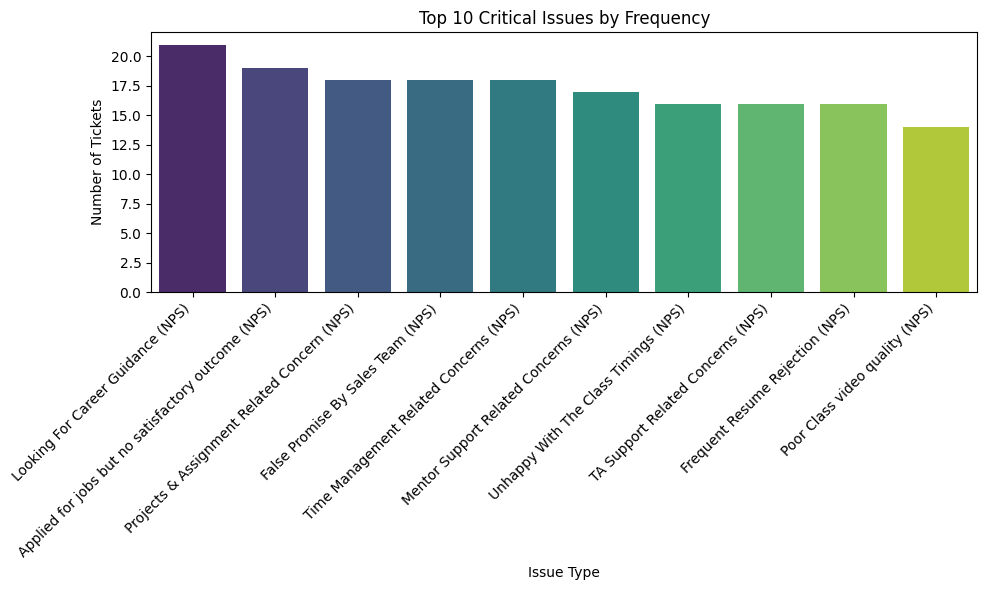

In [ ]:
# Example: Bar Chart for Top N Critical Issues by Frequency
# Using the previously calculated issue_freq
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 10 # You can adjust N
top_issues_plot_data = issue_freq.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_issues_plot_data.index, y=top_issues_plot_data.values, palette='viridis')
plt.title(f'Top {top_n} Critical Issues by Frequency')
plt.xlabel('Issue Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

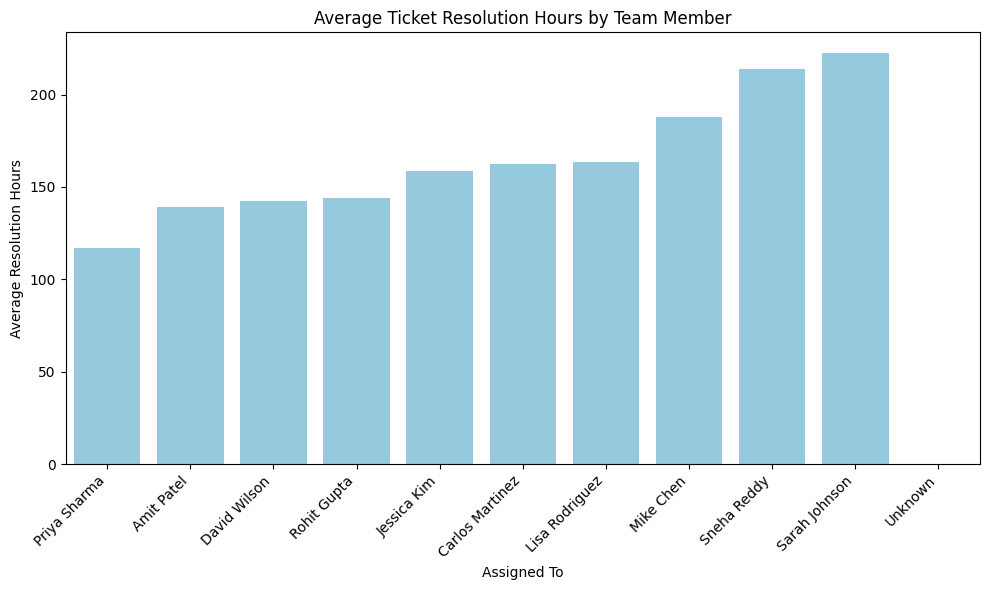

In [ ]:
# Example: Bar Chart for Average Ticket Resolution Hours by Team Member
# Using the previously calculated team_performance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=team_performance.index, y=team_performance.values, color='skyblue')
plt.title('Average Ticket Resolution Hours by Team Member')
plt.xlabel('Assigned To')
plt.ylabel('Average Resolution Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

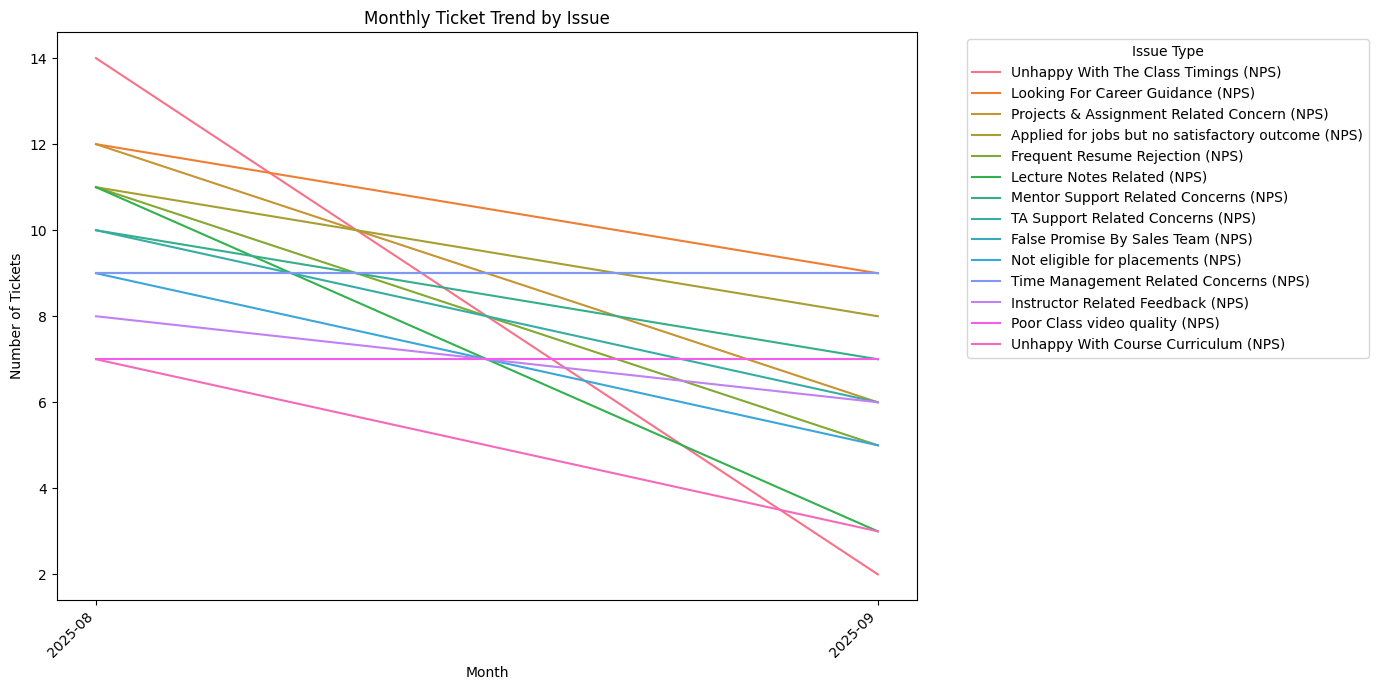

In [ ]:
# Example: Line Plot for Monthly Ticket Trend by Issue
# Using the previously calculated seasonal_patterns
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=seasonal_patterns, x='Month', y='Ticket_Count', hue='Issue 2 - NPS')
plt.title('Monthly Ticket Trend by Issue')
plt.xlabel('Month')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Issue Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## SQL Queries for Automated Data Quality Checks

Here are some SQL queries that can be used for automated data quality checks based on the issues identified in the data audit:

In [ ]:
-- 1. Check for duplicate Ticket Numbers
SELECT "Ticket No", COUNT(*)
FROM your_table_name  -- Replace with your actual table name
GROUP BY "Ticket No"
HAVING COUNT(*) > 1;

SyntaxError: invalid syntax (ipython-input-4163150642.py, line 1)

*   **Purpose:** Identifies if there are any duplicate entries based on the unique identifier, "Ticket No".

In [ ]:
-- 2. Check for missing values in Critical Columns
SELECT COUNT(*) AS MissingCriticalInfoCount
FROM your_table_name  -- Replace with your actual table name
WHERE "Ticket No" IS NULL
   OR "Created Date" IS NULL
   OR "Assigned To" IS NULL
   OR "Resolved Date" IS NULL  -- Depending on whether resolved date is always expected
   OR "Program Name" IS NULL
   OR "Issue 2 - NPS" IS NULL
   OR "Status" IS NULL
   OR "Sub Status" IS NULL;

SyntaxError: invalid syntax (ipython-input-3726838516.py, line 1)

*   **Purpose:** Counts rows where critical columns have missing values. Adjust the WHERE clause based on which critical columns should *never* be null.

In [ ]:
-- 3. Validate Date Consistency (Resolved Date not before Created Date)
SELECT COUNT(*) AS InconsistentDateCount
FROM your_table_name  -- Replace with your actual table name
WHERE "Resolved Date" IS NOT NULL
  AND "Created Date" IS NOT NULL
  AND "Resolved Date" < "Created Date";

SyntaxError: invalid syntax (ipython-input-783782960.py, line 1)

*   **Purpose:** Checks for logical inconsistencies where the resolved date is recorded as being before the created date.

In [ ]:
-- 4. Check for Status and Sub Status Inconsistency (Complete status with pending sub-status)
SELECT COUNT(*) AS StatusSubStatusInconsistencyCount
FROM your_table_name  -- Replace with your actual table name
WHERE LOWER(Status) = 'complete'
  AND (LOWER("Sub Status") LIKE '%pending%'
       OR LOWER("Sub Status") LIKE '%in progress%'
       OR LOWER("Sub Status") LIKE '%open%');

SyntaxError: invalid syntax (ipython-input-1314889556.py, line 1)

*   **Purpose:** Identifies rows where a ticket is marked as 'Complete' but its sub-status indicates it is still pending or in progress, addressing the inconsistency found in the data audit.

In [ ]:
-- 5. Validate NPS Rating Range (assuming 0-10 range)
SELECT COUNT(*) AS InvalidNPSRatingCount
FROM your_table_name  -- Replace with your actual table name
WHERE "NPS Rating" IS NOT NULL
  AND ("NPS Rating" < 0 OR "NPS Rating" > 10);

SyntaxError: invalid syntax (ipython-input-3626221508.py, line 1)

## Additional External Research or Industry Benchmarking

To gain a broader perspective and enhance the insights from this analysis, consider conducting additional external research or benchmarking against industry standards:

*   **Industry Benchmarks for Support Ticket Metrics:** Research average resolution times, first response times, and customer satisfaction scores (like NPS) for similar educational or service-based industries. This can help evaluate the performance metrics calculated in Task 2 against industry norms.
*   **Common Issues in Online Learning/EdTech Platforms:** Explore reports or studies on common challenges and pain points faced by learners in online educational settings. This can provide context for the issues identified in the 'Issue 2 - NPS' column and reveal if there are other prevalent issues not captured in this dataset.
*   **Best Practices in Learner Support:** Research best practices in learner support, ticket management systems, and customer service within the education technology sector. This can inform strategies for improving resolution processes, communication, and overall support quality.
*   **Impact of Program Structure/Delivery on Support Issues:** Investigate if there is external research on how different online program structures (e.g., self-paced vs. instructor-led, cohort-based) might correlate with the types and volume of support issues generated.
*   **Root Cause Analysis Methodologies:** Explore different methodologies for conducting root cause analysis (e.g., 5 Whys, Fishbone Diagram) that could be applied to delve even deeper into the underlying reasons for the critical issues identified.
*   **Data Privacy and Security Regulations:** If handling sensitive learner data, research relevant data privacy and security regulations (e.g., GDPR, FERPA) to ensure compliance in data storage, analysis, and reporting.

Incorporating findings from external research and benchmarking can provide valuable context, highlight areas for improvement based on industry best practices, and inform strategic decisions for enhancing the learner support experience.

In [ ]:
# Conceptual process automation suggestions

# Suggestion 1: Automate ticket assignment
# Based on keywords in 'Issue 2 - NPS' or 'Ticket All Remarks'
# Example: if 'Issue 2 - NPS' is 'Projects & Assignment Related Concern (NPS)', assign to a specific team/member.
# Tools: Many ticket management systems have built-in automation rules based on ticket fields.

# Suggestion 2: Set up SLA alerts
# If a ticket's resolution time exceeds a defined Service Level Agreement (SLA), trigger an alert.
# Example: If 'Status' is not 'Complete' and time since 'Created Date' > 48 hours, send notification to team lead.
# Tools: Ticket management systems often have SLA monitoring and alert features.

# Suggestion 3: Implement automated data quality checks
# Schedule regular checks for inconsistencies (e.g., Complete status with Pending sub-status)
# Example: Run SQL queries (like the ones we discussed) daily/weekly in the database.
# Tools: Database scheduling tools (e.g., cron jobs, SQL Agent), data validation scripts.

# Suggestion 4: Automate reporting
# Generate and distribute KPI reports automatically on a weekly/monthly basis.
# Example: Use a dashboarding tool to connect to the data source and schedule report delivery.
# Tools: Dashboarding tools (e.g., Tableau, Power BI, Looker Studio), reporting services.

process_improvements = [
    "Automate ticket assignment based on issue keywords to reduce manual triage.",
    "Set SLA alerts if resolution time exceeds 48 hours.",
    "Implement weekly data quality audits to catch missing information early.",
    "Automate the generation and distribution of KPI reports."
]

review_roles = {
    "Operations Manager": "Review KPIs monthly and allocate resources accordingly.",
    "Team Leads": "Monitor team resolution efficiency weekly and act on SLA breaches.",
    "Data Analyst": "Update dashboard weekly and report anomalies immediately."
}

print("\n=== Process Improvement Suggestions ===")
for p in process_improvements:
    print("-", p)

print("\n=== Review Roles & Frequency ===")
for role, action in review_roles.items():
    print(f"{role}: {action}")


=== Process Improvement Suggestions ===
- Automate ticket assignment based on issue keywords to reduce manual triage.
- Set SLA alerts if resolution time exceeds 48 hours.
- Implement weekly data quality audits to catch missing information early.
- Automate the generation and distribution of KPI reports.

=== Review Roles & Frequency ===
Operations Manager: Review KPIs monthly and allocate resources accordingly.
Team Leads: Monitor team resolution efficiency weekly and act on SLA breaches.
Data Analyst: Update dashboard weekly and report anomalies immediately.


# Annexure

## Data Dictionary & Context

| Column Name         | Description                | Business Context                 |
| :------------------ | :------------------------- | :------------------------------- |
| Ticket No           | Unique identifier          | System-generated ticket number   |
| Created Date/Time   | When ticket was raised     | Learner feedback submission time |
| Assigned To         | Team member handling ticket| Our resolution team assignments  |
| Resolved Date/Time  | When ticket was closed     | Resolution efficiency tracking   |
| Program Name        | Academy/AIML/DevOps/DSML   | Different educational programs   |
| Issue 2 - NPS       | Primary issue category     | Standardized issue classification|
| Status              | Complete/Pending           | Ticket resolution status         |
| Sub Status          | Detailed status            | Workflow stage information       |
| Ticket All Remarks  | Detailed feedback          | Learner complaints and resolution notes |
| Phone/Email         | Contact information        | For follow-up communications     |

In [ ]:
# Save the final cleaned DataFrame to an Excel file
final_excel_path = "NPS_Tracker_Final_Cleaned.xlsx"
df.to_excel(final_excel_path, index=False)

print(f"Final cleaned data saved to: {final_excel_path}")

Final cleaned data saved to: NPS_Tracker_Final_Cleaned.xlsx
